**Workflow**

Set Google Colab Runtime type to GPU, check if GPU is being used with !nvidia-smi command.
Login to your Roboflow account and get your workspace API key by creating a project.
Login to your Hugging Face account and get your access token.

1. Import a Roboflow building crack dataset
   * Search and select a building crack dataset after logging into Roboflow
   * Login to your Hugging Face account and create an empty data repository.
   * Convert the imported dataset into a Hugging Face compatible one. You can use the roboflow2huggingface library for this.
   * Upload the dataset to the Hugging Face repository you just created.

2. Load and explore dataset
   * Load the dataset from the Hugging Face repository you created above.
   * Display the contents of the dataset
   * Load an display an image from the dataset and corresponding annotation overlaid on it.
   * Convert class names (tumor, no-tumor) to numerical labels

Note: Steps 3-5 are common workflow steps for Hugging Face DETR models
3. Preprocess the dataset and apply transforms
   * Resize the data to Apply data augmentations like flip and rotate
   * Format annotations to convert them to Coco compatible ones
   * Load a Conditional Transformer based object detection model check point.
   * Instantiate an image processor using the checkpoint
   * Append images and annotations into lists and pass them through the image processor

4.  Batch images and masks
    * Write a function to create to put batches of images together.
    * Add padding to images corresponding to the largest image in a batch
    * Create a corresponding pixel_mask to distinguish between real pixels (1) and padding (0).

5. Load and train a Conditional DETR model for detection of machinery
    * Load the model with AutoModelForObjectDetection using the same checkpoint used in the preprocessing.
    * Define training hyperparameters
    * Pass the training arguments to Trainer
    * Compile model, add callbacks, and run the training
    * (Optional) Upload the trained model to Hugging Face hub

6. Run inference and evaluate
    * Load a random image from the test dataset
    * Run inference on the image using the trained model
    * Display the images with ground truth and predicted object bounding boxes overlaid together
    * Write a function to compute the mean IOU metric value for object detection.
    * Use the function to estimate mean IOU for the prediction and print it.

In [ ]:
!nvidia-smi

Thu Aug 24 23:34:39 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.105.17   Driver Version: 525.105.17   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   50C    P8    10W /  70W |      0MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [ ]:
!pip install -q datasets evaluate timm albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.3/519.3 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 23.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 11.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 16.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 15.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 19.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.8 MB/s eta 0:00:00


In [ ]:
!pip install transformers==4.31.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 25.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 79.2 MB/s eta 0:00:00


In [ ]:
import transformers
print(transformers.__version__)


4.31.0


In [ ]:
!pip install roboflow2huggingface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.4/95.4 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.0/49.0 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 11.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 15.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 22.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 6.7 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.5.0-py2.py3-none-any.whl size=116934 sha256=919f29a44820488a54733a323af0993bb85dab9e674a6c19c32842e9d4b29721
  Stored in directory: /root/.cache/pip/wheels/90/d4/f7/9404e5db0116bd4d43e5666eaa3e70ab53723e1e3ea40c9a95
  Created wheel f

In [ ]:
!pip install accelerate -U

In [ ]:
# Login to Huggingface hub
from huggingface_hub import login
login(token='Your token')

Token will not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: write).
Your token has been saved to /root/.cache/huggingface/token
Login successful


Sample datasets to add

crack_det-I: https://universe.roboflow.com/crack-7rsjb/crack-detection-ol3yi

crack_det-II: https://universe.roboflow.com/its-c0m3e/crackdetect_2

# Import first crack detection dataset into Hugging Face from Roboflow

In [ ]:
# Create a repository on Huggingface and asign it a name, privacy type and repository type
from huggingface_hub import create_repo
create_repo("crack_det-single-class", repo_type = "dataset", private=True)

RepoUrl('https://huggingface.co/datasets/akar49/crack_det-single-class', endpoint='https://huggingface.co', repo_type='dataset', repo_id='akar49/crack_det-single-class')

In [ ]:
#Convert Roboflow dataset to Hugging Face compatible one
from roboflow2huggingface import roboflow_to_huggingface_pipeline

roboflow_to_huggingface_pipeline(
    roboflow_universe_url='https://universe.roboflow.com/crack-7rsjb/crack-detection-ol3yi/dataset/1',
    roboflow_api_key='XXX',  ## add the API key for your Roboflow account
    hf_dataset_id='Your dataset ID',
    hf_write_token='Your token'
)

loading Roboflow workspace...
loading Roboflow project...


Extracting Dataset Version Zip to roboflow_dataset in coco:: 100%|██████████| 2402/2402 [00:00<00:00, 3892.10it/s]


valid.zip:   0%|          | 0.00/2.96M [00:00<?, ?B/s]

Upload 5 LFS files:   0%|          | 0/5 [00:00<?, ?it/s]

train.zip:   0%|          | 0.00/10.6M [00:00<?, ?B/s]

valid-mini.zip:   0%|          | 0.00/16.3k [00:00<?, ?B/s]

thumbnail.jpg:   0%|          | 0.00/105k [00:00<?, ?B/s]

test.zip:   0%|          | 0.00/1.51M [00:00<?, ?B/s]

#Display dataset content, sample image from dataset with annotation

In [ ]:
# Load the dataset
from datasets import load_dataset

# Retrieve an example from the training set
ds = load_dataset("Your dataset name", name="full")
example = ds['train'][0]


Extracting data files:   0%|          | 0/3 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [ ]:
#Print dataset contents
ds

DatasetDict({
    train: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 1673
    })
    validation: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 477
    })
    test: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 244
    })
})

In [ ]:
#Print contents of 1 sample from the dataset
example

{'image_id': 824,
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=200x200>,
 'width': 200,
 'height': 200,
 'objects': {'id': [825],
  'area': [35640],
  'bbox': [[4.0, 1.0, 180.0, 198.0]],
  'category': [0]}}

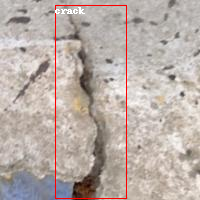

In [ ]:
# Import necessary libraries
import numpy as np

import os

from PIL import Image, ImageDraw

image = ds["train"][50]["image"]

annotations = ds["train"][50]["objects"]

draw = ImageDraw.Draw(image)

categories = ds["train"].features["objects"].feature["category"].names

id2label = {index: x for index, x in enumerate(categories, start=0)}

label2id = {v: k for k, v in id2label.items()}

for i in range(len(annotations["id"])):

    box = annotations["bbox"][i - 1]

    class_idx = annotations["category"][i - 1]

    x, y, w, h = tuple(box)

    draw.rectangle((x, y, x + w, y + h), outline="red", width=1)

    draw.text((x, y), id2label[class_idx], fill="white")

image

In [ ]:
# Check the meaning of labels in dataset
id2label

{0: 'crack'}

In [ ]:
# Import AutoImageProcessor from transformers
from transformers import AutoImageProcessor, ConditionalDetrForObjectDetection

# Specify the checkpoint for the DETR model with ResNet-50 backbone

checkpoint = "microsoft/conditional-detr-resnet-50"

# Instantiate an AutoImageProcessor from the specified checkpoint
image_processor = AutoImageProcessor.from_pretrained(checkpoint)

Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration.


In [ ]:
# Import necessary libraries
import albumentations
import numpy as np
import torch

# Define the transformation using Albumentations
transform = albumentations.Compose(
    [
        albumentations.Resize(480, 480),
        albumentations.HorizontalFlip(p=1.0),
        albumentations.RandomBrightnessContrast(p=1.0),
    ],
    bbox_params=albumentations.BboxParams(format="coco", label_fields=["category"]),
)

In [ ]:
def formatted_anns(image_id, category, area, bbox):
    annotations = []
    for i in range(0, len(category)):
        new_ann = {
            "image_id": image_id,
            "category_id": category[i],
            "isCrowd": 0,
            "area": area[i],
            "bbox": list(bbox[i]),
        }
        annotations.append(new_ann)

    return annotations

In [ ]:
# transforming a batch
def transform_aug_ann(examples):
    image_ids = examples["image_id"]
    images, bboxes, area, categories = [], [], [], []
    for image, objects in zip(examples["image"], examples["objects"]):
        image = np.array(image.convert("RGB"))[:, :, ::-1]
        out = transform(image=image, bboxes=objects["bbox"], category=objects["category"])

        area.append(objects["area"])
        images.append(out["image"])
        bboxes.append(out["bboxes"])
        categories.append(out["category"])

    targets = [
        {"image_id": id_, "annotations": formatted_anns(id_, cat_, ar_, box_)}
        for id_, cat_, ar_, box_ in zip(image_ids, categories, area, bboxes)
    ]

    return image_processor(images=images, annotations=targets, return_tensors="pt")

In [ ]:
ds["train"] = ds["train"].with_transform(transform_aug_ann)
ds["train"][10]



{'pixel_values': tensor([[[2.1804, 2.1804, 2.1804,  ..., 2.2489, 2.2489, 2.2489],
          [2.1804, 2.1804, 2.1804,  ..., 2.2489, 2.2489, 2.2489],
          [2.1804, 2.1804, 2.1804,  ..., 2.2489, 2.2489, 2.2489],
          ...,
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489]],
 
         [[0.5028, 0.5028, 0.5028,  ..., 0.9405, 0.9405, 0.9405],
          [0.5028, 0.5028, 0.5028,  ..., 0.9405, 0.9405, 0.9405],
          [0.5028, 0.5028, 0.5028,  ..., 0.9405, 0.9405, 0.9405],
          ...,
          [0.8880, 0.8880, 0.8880,  ..., 0.8179, 0.8179, 0.8179],
          [0.8880, 0.8880, 0.8880,  ..., 0.8179, 0.8179, 0.8179],
          [0.8880, 0.8880, 0.8880,  ..., 0.8179, 0.8179, 0.8179]],
 
         [[2.2566, 2.2566, 2.2566,  ..., 2.6400, 2.6400, 2.6400],
          [2.2566, 2.2566, 2.2566,  ..., 2.6400, 2.6400, 2.6400],
          [2.2566, 2.256

In [ ]:
def collate_fn(batch):
    # Extract pixel values from each item in the batch
    pixel_values = [item["pixel_values"] for item in batch]
    # Pad the pixel values using the image processor
    encoding = image_processor.pad(pixel_values, return_tensors="pt")
    # Extract labels from each item in the batch
    labels = [item["labels"] for item in batch]
    batch = {}
    # Construct the batch dictionary
    batch["pixel_values"] = encoding["pixel_values"]
    batch["pixel_mask"] = encoding["pixel_mask"]
    batch["labels"] = labels
    return batch

In [ ]:
# Define the model
from transformers import AutoModelForObjectDetection

model = AutoModelForObjectDetection.from_pretrained(
    checkpoint,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

Some weights of ConditionalDetrForObjectDetection were not initialized from the model checkpoint at microsoft/conditional-detr-resnet-50 and are newly initialized because the shapes did not match:
- class_labels_classifier.weight: found shape torch.Size([91, 256]) in the checkpoint and torch.Size([1, 256]) in the model instantiated
- class_labels_classifier.bias: found shape torch.Size([91]) in the checkpoint and torch.Size([1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Set hyperparameters
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="only-crack-I",
    per_device_train_batch_size=2,
    num_train_epochs=10,
    fp16=True,
    save_steps=20,
    logging_steps=10,
    learning_rate=1e-5,
    weight_decay=1e-4,
    save_total_limit=2,
    remove_unused_columns=False,
    push_to_hub=True,
)

In [ ]:
#Start training
from transformers import Trainer

trainer = Trainer(
    model=model,

    args=training_args,
    data_collator=collate_fn,
    train_dataset=ds["train"],
    tokenizer=image_processor,
)

trainer.train()

Cloning https://huggingface.co/akar49/only-crack-I into local empty directory.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Step,Training Loss
10,157.628700
20,100.386700
30,23.511200
40,7.110700
50,3.223500
60,2.568300
70,2.509100
80,2.199800
90,2.162500
100,1.970200


TrainOutput(global_step=8370, training_loss=1.2913680737448707, metrics={'train_runtime': 6902.8378, 'train_samples_per_second': 2.424, 'train_steps_per_second': 1.213, 'total_flos': 8.3502317517696e+18, 'train_loss': 1.2913680737448707, 'epoch': 10.0})

In [ ]:
# Upload trained model to Huggingface Hub
trainer.push_to_hub()

#Display sample crack detection result, compute IoU with respect to ground truth and display

In [ ]:
image = ds["test"][25]["image"]
box_gt=  ds["test"][25]["objects"]["bbox"]
box_gt= [item for sublist in box_gt for item in sublist]


In [ ]:
from transformers import AutoImageProcessor, AutoModelForObjectDetection
from shapely.geometry import Polygon
import torch
image_processor = AutoImageProcessor.from_pretrained("your trained model")
model = AutoModelForObjectDetection.from_pretrained("your trained model")


In [ ]:
with torch.no_grad():
    inputs = image_processor(images=image, return_tensors="pt")
    outputs = model(**inputs)
    target_sizes = torch.tensor([image.size[::-1]])
    results = image_processor.post_process_object_detection(outputs, threshold=0.5, target_sizes=target_sizes)[0]

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    print(
        f"Detected {model.config.id2label[label.item()]} with confidence "
        f"{round(score.item(), 3)} at location {box}"
    )

Detected crack with confidence 0.696 at location [1.27, 0.01, 52.38, 123.49]


In [ ]:
# Display result overlaid on image
from PIL import Image, ImageDraw
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

draw = ImageDraw.Draw(image)

def calculate_iou(box_1, box_2):
    poly_1 = Polygon(box_1)
    poly_2 = Polygon(box_2)
    iou = poly_1.intersection(poly_2).area / poly_1.union(poly_2).area
    return iou

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    x, y, x2, y2 = tuple(box)
    xgt, ygt, x2gt, y2gt = tuple(box_gt)


    draw.rectangle((x, y, x2, y2), outline="red", width=1)
    draw.rectangle((xgt, ygt, x2gt, y2gt), outline="green", width=1)
    draw.text((x, y), "pred(red)", fill="white")
    draw.text((x2gt, y2gt), "gt(green)", fill="white")


# Object detection accuracy metric calculation

In [ ]:
from shapely.geometry import Polygon

x, y, x2, y2 = tuple(box)
xgt, ygt, x2gt, y2gt = tuple(box_gt)

def calculate_iou(box1, box2):
    poly_1 = Polygon(box_1)
    poly_2 = Polygon(box_2)
    iou = poly_1.intersection(poly_2).area / poly_1.union(poly_2).area
    return iou

box_1 = [[x, y], [x2, y], [x2, y2], [x, y2]]
box_2 = [[xgt, ygt], [x2gt, ygt], [x2gt, y2gt], [xgt, y2gt]]

iou= calculate_iou(box_1, box_2)


Text(0.5, 1.0, 'IOU is: 0.811')

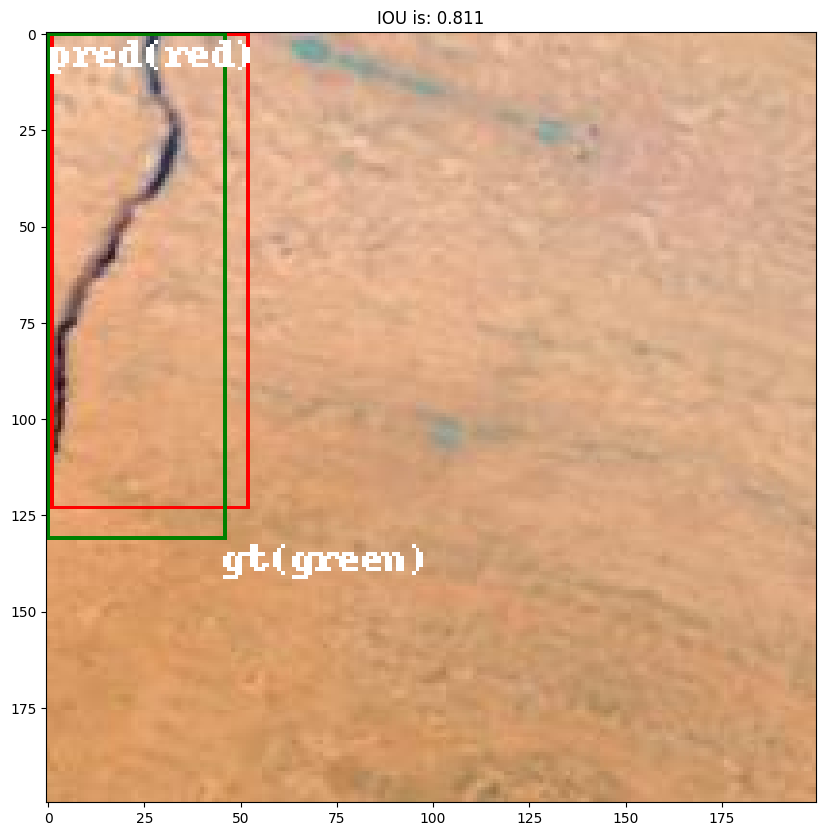

In [ ]:
fig = plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.title("IOU is: "+str(round(iou, 3)))

